<a href="https://colab.research.google.com/github/DarkLyng/Proyecto_Modelos/blob/main/Proyecto_Modelos_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---
# **Proyecto de Modelos Probabilísticos - Contoso Sales**

**Grupo 1 Subgrupo 16**

**Integrantes**

*   Darlyng Rojas Ramírez - C06888
*   Adrian Mendez Chavarría -


**Objetivo**

Analizar el rendimiento de una empresa a partir de las herramientas probabilísticas
estudiadas en el curso y brindando recomendaciones que podría tomar la empresa para
mejorar o corregir aspectos del negocio.




---





# **Proceso ETL**

# **Parte 1. Preparar datos**

Primero se importan las librerias y se cargan los datos.

In [255]:
# Bibliotecas de Python

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import csv

warnings.filterwarnings('ignore')

In [256]:
RUTA_XLSX = "/content/Contoso Sales.xlsx"
RUTA_FACT = "/content/FactSales.txt"

In [257]:
# Carga el archivo xlsx
xls = pd.ExcelFile(RUTA_XLSX)
print(xls.sheet_names)

['DimChannel', 'DimGeography', 'DimProduct', 'DimProductCategory', 'DimProductSubCategory', 'DimPromotion', 'DimStores']


In [258]:
# Crea una lista con los nombres de las hojas de Contoso Sales
tabs = ['DimChannel', 'DimGeography', 'DimProduct', 'DimProductCategory', 'DimProductSubCategory', 'DimPromotion', 'DimStores']
tablas = []

In [259]:
# Se agrega en la lista los nombres de las hojas del xlsx
for tab in tabs:
  df = pd.read_excel("/content/Contoso Sales.xlsx", sheet_name=tab,)
  tablas.append(df)

In [260]:
# Lee el el archivo FactSales, lo separa y agrega a la lista "tablas" los datos del txt
ventas = pd.read_csv(RUTA_FACT, sep="\t")
tablas.append(ventas)

In [261]:
# Muestra la cantidad de tablas que se cargaron a la lista
print(f"Total de tablas cargadas en la lista: {len(tablas)}")

Total de tablas cargadas en la lista: 8


In [262]:
#print(tablas)

# **Parte 2. Transformación**

Se crean 7 dataframes diferentes con los datos de "tablas", el de df_ventas contiene toda la información de FactSales.txt.

In [263]:
df_channel = tablas[0]        # Índice 0: Canal
df_geography = tablas[1]      # Índice 1: Geografía
df_product= tablas[2]         # Índice 2: Productos
df_productcat = tablas[3]     # Índice 3: Categoría de Productos
df_productsubcat = tablas[4]  # Índice 4: Subcategoría de Productos
df_promotion = tablas[5]      # Índice 5: Promociones
df_stores = tablas[6]         # Índice 0: Tiendas
df_ventas = tablas[-1]        # Último índice

Se cambia el dtype de ciertas columnas de df_ventas porque no corresponden al tipo de datos que deberían de tener para realizar su análisis.

In [264]:
# Convierte números como '1 980 ' / '186,9' a float (1980.0 / 186.9) sin perder datos.
def limpiar_numero(serie):
    return (
        serie.astype(str).str.replace(r"\s+", "", regex=True).str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors='coerce').fillna(0).astype(float))

In [265]:
# Se cambia de object a datetime
df_ventas['DateKey'] = pd.to_datetime(df_ventas['DateKey'], errors='coerce')

In [266]:
# Se cambia de object a int
df_ventas['ReturnQuantity'] = pd.to_numeric(df_ventas['ReturnQuantity'], errors='coerce').fillna(0).astype(int)

In [267]:
# Se cambia de object a int
df_ventas['Cantidad_total'] = pd.to_numeric(df_ventas['Cantidad_total'], errors='coerce').fillna(0).astype(int)

In [268]:
# Se cambia de object a float
df_ventas['Precio_unitario'] = limpiar_numero(df_ventas['Precio_unitario'])

In [269]:
# Se cambia de object a float
df_ventas['Ingresos'] = limpiar_numero(df_ventas['Ingresos'])

In [270]:
# Columnas auxiliares de fecha para el analisis de estacionalidad
df_ventas['Año'] = df_ventas['DateKey'].dt.year

In [271]:
tablas[-1] = df_ventas

# **Parte 3. Carga**

Se realiza el conteo de filas, columnas y datos faltantes de cada dataframe por medio de cada índice de "tablas".

In [272]:
# Muestra la cantidad de filas columnas y datos faltantes del dataframe
print(" Conteo de filas, columnas y datos fantantes \n")

for i, df in enumerate(tablas):
    # Filas y columnas
    filas = df.shape[0]
    columnas = df.shape[1]
    # Total de celdas vacías o con errores en toda la tabla
    celdas_vacias_tot = df.isnull().sum().sum()

    # Nombre original usando la lista tabs
    nombre_tabla = tabs[i] if i < len(tabs) else "FactSales"
    print(f"Índice [{i}] - Tabla: '{nombre_tabla}'")
    print(f" Filas: {filas}")
    print(f" Columnas: {columnas}")
    print(f" Total de celdas vacías o errores encontrados: {celdas_vacias_tot}")
    print("-" * 40)

 Conteo de filas, columnas y datos fantantes 

Índice [0] - Tabla: 'DimChannel'
 Filas: 4
 Columnas: 2
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [1] - Tabla: 'DimGeography'
 Filas: 674
 Columnas: 3
 Total de celdas vacías o errores encontrados: 3
----------------------------------------
Índice [2] - Tabla: 'DimProduct'
 Filas: 1690
 Columnas: 14
 Total de celdas vacías o errores encontrados: 614
----------------------------------------
Índice [3] - Tabla: 'DimProductCategory'
 Filas: 8
 Columnas: 2
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [4] - Tabla: 'DimProductSubCategory'
 Filas: 44
 Columnas: 3
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [5] - Tabla: 'DimPromotion'
 Filas: 28
 Columnas: 7
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [6] - Tabla: 'DimStores'
 Filas: 310


**Interpretación del tamaño de los dataframes y sus celdas faltantes**
*   DimChannel: Esta tabla contiene la información de los medios de ventas que tiene la empresa, estos corresponden a ventas en la tienda, en línea, catálogo y revendedores(distribuidores), están representados mediante 2 variables. No contiene celdas vacías o con errores.

*   DimGeography: Esta tabla contiene las diferentes ubicaciones geográficas de las tiendas de la empresa Contoso, en las cuales se observan 674 registros diferentes de ubicaciones, en diversos países mediante 3 variables. Se observan 3 celdas vacías, pero no representan un gran problema, por lo tanto, no es necesario eliminarlas.

*   DimProduct: Esta tabla representa los productos únicos que vende la empresa con un total de 1690 productos, además muestra sus características y precio mediante 14 columnas. Se observan 614 celdas vacías o con errores, esta celdas son especificamente relacionadas a su tamaño y peso, no representa un mayor problema a menos que se analicen esta variables, en ese caso se deberán de eliminar.    

*   DimProductCategory: Esta tabla cuenta con las 8 categorías de los productos que vende la empresa, como lo es audio, TV o video, computadoras celulares, entre otras. Esto se observa mediante 2 variables. No se observan celdas vacías o con errores.  

*   DimProductSubCategory: Esta tabla corresponde a las subcategorías de los productos que vende la empresa, se observan 44 subcategorías pero al prestar atención se nota que faltan 4, si se toma en cuenta el código o número de la primera columna. Cuenta con 3 variables o columnas. A simple vista no se observan celdas vacías, pero si se toma en cuenta lo mencionado anteriormente, entonces presenta 4 filas vacías.

*   DimPromotion: En esta tabla se muestran las 28 promociones que ha tenido la empresa históricamente, además de 7 carácterísticas como porcentaje y fecha de validez. No presenta celdas vacías.

*   DimStores: En esta tabla se observa que Contoso cuenta con 310 tiendas, que son descritas mediante 6 variables o columnas que muestran su ubicación, cantidad de empleados, nombre, entre otros datos.Presenta solo una celda vacía pero no genera un gran problema en los datos.

*   FactSales: Esta tabla es la más importante del análisis porque contiene todas las ventas realizadas por la empresa, cuenta con 2282482 ventas y cada una cuenta con 14 variables que describen la venta. No presenta celdas vacías.



Se obtiene un análisis estadístico de cada índice de "tablas "por medio de una función que llamarla despliega el tipo de dato, el total de filas, filas únicas y datos faltantes.

Seguidamente se obtiene de las variables numéricas o continuas, la media, mediana, varianza, desviación estandar, los cuartiles, la inclinación, curtosis, valores máximos, valores mínimos y los límites para los outliers.

Para las variables cualitativas o discretas se obtiene la frecuencia de los datos y la probabilidad empírica de estos.

In [273]:
# Función que permite obtener un análisis estadístico de cada hoja de Contoso Sales

def analizar_tabla_lista(df, nombre_tabla):
    resultados= {}
    print(f"Análisis de la tabla: {nombre_tabla}")

    for col in df.columns:
        dtype = df[col].dtype
        total_valores = len(df[col])
        valores_unicos = df[col].nunique()
        faltantes = df[col].isnull().sum()

        print(f"\n Columna: '{col}' | Tipo: {dtype}")
        print(f"  - Total de valores: {total_valores}")
        print(f"  - Cardinalidad (Valores únicos): {valores_unicos}")
        print(f"  - Datos faltantes: {faltantes} ({ (faltantes/total_valores)*100:.2f}%)")

        es_identificador = col.endswith('Key') or col.endswith('ID')

        try:
            es_numerica = np.issubdtype(dtype, np.number)
        except TypeError:
            es_numerica = False

        # Variables numéricas continuas o cuantitativas
        if es_numerica and valores_unicos > 10 and not es_identificador:
            print("  - Clasificación: Variable numérica continua")

            media = df[col].mean()
            q1 = df[col].quantile(0.25)   # Primer Cuartil (25%)
            mediana = df[col].median()
            q3 = df[col].quantile(0.75)   # Tercer Cuartil (75%)
            desv_est = df[col].std()
            varianza = df[col].var()
            inclinacion = df[col].skew()  # Inclinación(Skewness)
            curtosis = df[col].kurt()     # Kurtosis
            val_min = df[col].min()
            val_max = df[col].max()
            # Cálculo de los outliers
            ric = q3 - q1
            limite_inferior_outlier = q1 - 1.5 * ric
            limite_superior_outlier = q3 + 1.5 * ric

            print(f"  - Valor esperado (Media): {media:.4f}")
            print(f"  - Cuartil 1 (Q1 - 25%): {q1:.4f}")
            print(f"  - Mediana: {mediana:.4f}")
            print(f"  - Cuartil 3 (Q3 - 75%): {q3:.4f}")
            print(f"  - Varianza: {varianza:.4f}")
            print(f"  - Desviación estándar: {desv_est:.4f}")
            print(f"  - Inclinación (Skewness): {inclinacion:.4f}")
            print(f"  - Kurtosis: {curtosis:.4f}")

            if abs(inclinacion) < 0.5:
                  print("  -  Distribución simétrica.")
            else:
                print(f"  - Distribución asimétrica a la {'derecha' if inclinacion > 0 else 'izquierda'}.")

            print(f"  - Valor mínimo: {val_min:.4f}")
            print(f"  - Valor máximo: {val_max:.4f}")
            print(f"  - Rango intercuartílico (RIC): {ric:.4f}")
            print(f"  - Límites para outliers: [{limite_inferior_outlier:.2f} , {limite_superior_outlier:.2f}]")

        # Variables discretas o cualitativas (Frecuencia y probabilidad empírica)
        else:
            print("  - Clasificación: Variable cualitativa o discreta (Atributo/Llave)")
            frecuencias = df[col].value_counts(dropna=False).head(5)
            probabilidades = df[col].value_counts(dropna=False, normalize=True).head(5)

            print("  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):")
            for val, freq in frecuencias.items():
                prob = probabilidades[val]
                print(f"     Valor: {val} | Frecuencia: {freq} | Probabilidad: {prob:.4f} ({prob*100:.2f}%)")
    #return resultados


In [274]:
resumen_tablas = {}
for i, df in enumerate(tablas):
    nombre = tabs[i] if i < len(tabs) else "FactSales"
    resumen_tablas[nombre] = analizar_tabla_lista(df, nombre)

Análisis de la tabla: DimChannel

 Columna: 'ChannelKey' | Tipo: int64
  - Total de valores: 4
  - Cardinalidad (Valores únicos): 4
  - Datos faltantes: 0 (0.00%)
  - Clasificación: Variable cualitativa o discreta (Atributo/Llave)
  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):
     Valor: 1 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: 2 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: 3 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: 4 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)

 Columna: 'ChannelName' | Tipo: object
  - Total de valores: 4
  - Cardinalidad (Valores únicos): 4
  - Datos faltantes: 0 (0.00%)
  - Clasificación: Variable cualitativa o discreta (Atributo/Llave)
  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):
     Valor: Store | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: Online | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: Catalog | Frecuencia: 1 | Probabil

**Interpretación del análisis estadístico de cada dataframe de "tablas"**
*   DimChannel:
*   DimGeography:
*   DimProduct:
*   DimProductCategory:
*   DimProductSubCategory:
*   DimPromotion:
*   DimStores:
*   FactSales:


---



In [275]:
print("\nETL y analisis estadistico completados sobre el dataset COMPLETO.")


ETL y analisis estadistico completados sobre el dataset COMPLETO.


# **Modelo Relacional**

**Métricas de las tablas FactSales**

Se obtienen las siguientes métricas para obtener un resumen de los datos por medio de ciertos cálculos, los cuales nos funcionaran para entender el estado de la empresa.

In [276]:
cantidad_ventas = df_ventas['SalesQuantity'].sum()
print(f" Cantidad total de ventas (Unidades): {cantidad_ventas:.0f}")

 Cantidad total de ventas (Unidades): 36900410


In [277]:
cantidad_devoluciones = df_ventas['ReturnQuantity'].sum()
print(f" Cantidad total de devoluciones (Unidades): {cantidad_devoluciones:.0f}")

 Cantidad total de devoluciones (Unidades): 326308


In [278]:
cantidad_total = cantidad_ventas - cantidad_devoluciones
print(f" Cantidad total de ventas menos devoluciones (Cantidad Total): {cantidad_total:.0f}")

 Cantidad total de ventas menos devoluciones (Cantidad Total): 36574102


In [279]:
promedio_precio_unitario = df_product['UnitPrice'].mean()
print(f" Promedio precio unitario: {promedio_precio_unitario:.2f}")

 Promedio precio unitario: 316.92


In [280]:
numero_stores = df_stores['StoreKey'].count()
print(f" Número total de tiendas registradas: {numero_stores:}")

 Número total de tiendas registradas: 310


In [281]:
numero_stores_con_ventas = df_ventas['StoreKey'].nunique()
print(f" Número de tiendas con ventas reales: {numero_stores_con_ventas:,}")

 Número de tiendas con ventas reales: 306


In [282]:
numero_ordenes = len(df_ventas)
print(f" Número total de ordenes procesadas: {numero_ordenes:}")

 Número total de ordenes procesadas: 2282482


In [283]:
numero_ordenes_con_devolucion = len(df_ventas[df_ventas['ReturnQuantity'] > 0])
print(f" Ordenes con devolución: {numero_ordenes_con_devolucion:}")

 Ordenes con devolución: 318550


In [284]:
total_ingresos = df_ventas['Ingresos'].sum()
print(f" Total de ingresos históricos: {total_ingresos:.2f}")

 Total de ingresos históricos: 8370795160.61


In [285]:
metricas_txt = {
    "cantidad_ventas": float(cantidad_ventas),
    "cantidad_devoluciones": float(cantidad_devoluciones),
    "cantidad_total": float(cantidad_total),
    "promedio_precio_unitario": float(promedio_precio_unitario),
    "numero_stores": int(numero_stores),
    "numero_stores_con_ventas": int(numero_stores_con_ventas),
    "numero_ordenes": int(numero_ordenes),
    "numero_ordenes_con_devolucion": int(numero_ordenes_con_devolucion),
    "total_ingresos": float(total_ingresos),}

**Gráficos e historgramas de "tablas"**

In [ ]:
hallazgos = {}

In [ ]:
def guardar(nombre):
    plt.tight_layout()
    plt.savefig(f"figs/{nombre}.png", bbox_inches='tight')
    plt.close()

*   **Gráfico que muestra la cantidad de ventas que genera cada medio de distribución**

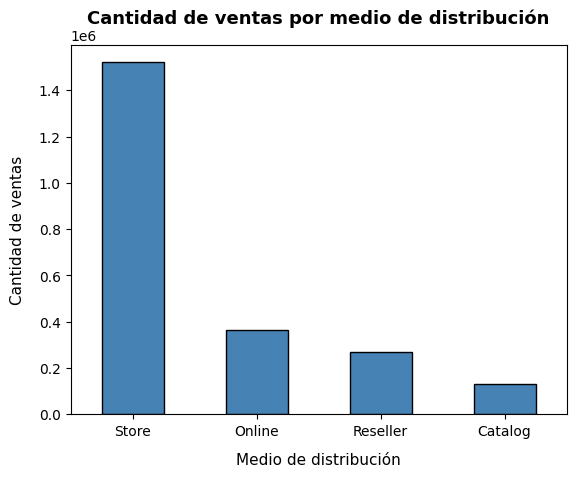

In [286]:
# Cambia los códigos a nombres
mapa_canales = dict(zip(tablas[0]['ChannelKey'], tablas[0]['ChannelName']))

# Cambia los datos y cuenta que tanto se aparecen
ventas_por_canal = tablas[7]['channelKey'].map(mapa_canales).value_counts()

ventas_por_canal.plot(kind='bar', color='steelblue', edgecolor='black', rot=0)
plt.title("Cantidad de ventas por medio de distribución", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Medio de distribución", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de ventas", fontsize=11, labelpad=10)
plt.show()
#guardar("01_ventas_por_canal")

*   **Gráfico que muestra las 10 marcas con mayor cantidad de ventas**

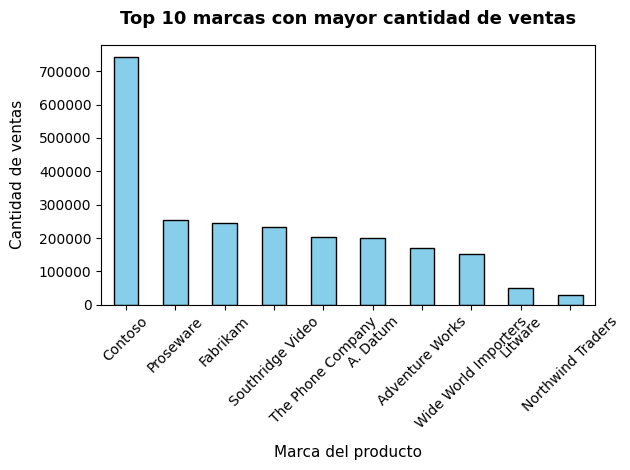

In [287]:
# Se obtiene la marca del producto vendido
df_marcas = tablas[7].merge(tablas[2][['ProductKey', 'BrandName']], on='ProductKey', how='left')
top_marcas = df_marcas['BrandName'].value_counts().head(10)

top_marcas.plot(kind='bar', color='skyblue', edgecolor='black', rot=45)
plt.title("Top 10 marcas con mayor cantidad de ventas", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Marca del producto", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de ventas", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()
#guardar("02_top10_marcas_ventas")

*   **Gráfico que muestra la cantidad de compras realizadas por distintas tiendas registradas por Contoso**

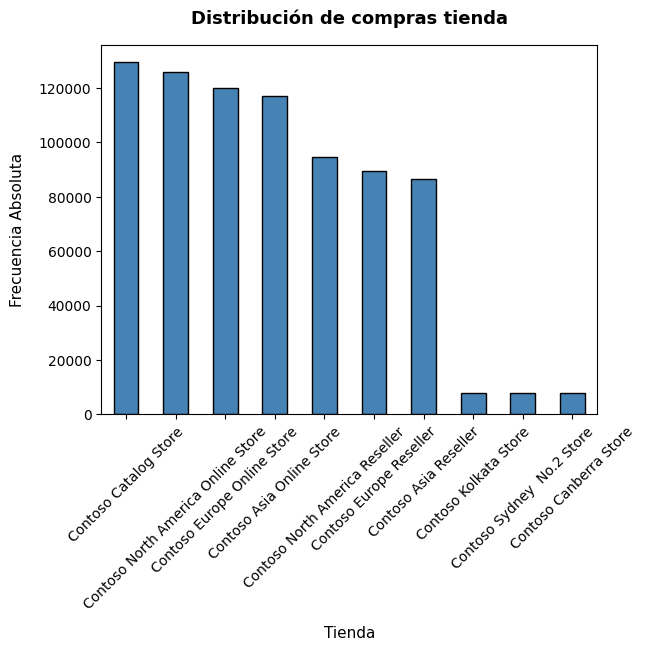

In [288]:
mapa_tiendas = dict(zip(tablas[6]['StoreKey'], tablas[6]['StoreName']))

ventas_por_tipo_tienda = tablas[7]['StoreKey'].map(mapa_tiendas).value_counts().head(10)

ventas_por_tipo_tienda.plot(kind='bar', color='steelblue', edgecolor='black', rot=45)
plt.title("Distribución de compras tienda", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Tienda", fontsize=11, labelpad=10)
plt.ylabel("Frecuencia Absoluta", fontsize=11, labelpad=10)
plt.show()
#guardar("03_top10_tiendas_ordenes")

*   **Gráfico que muestra los 10 productos más vendidos por la empresa**

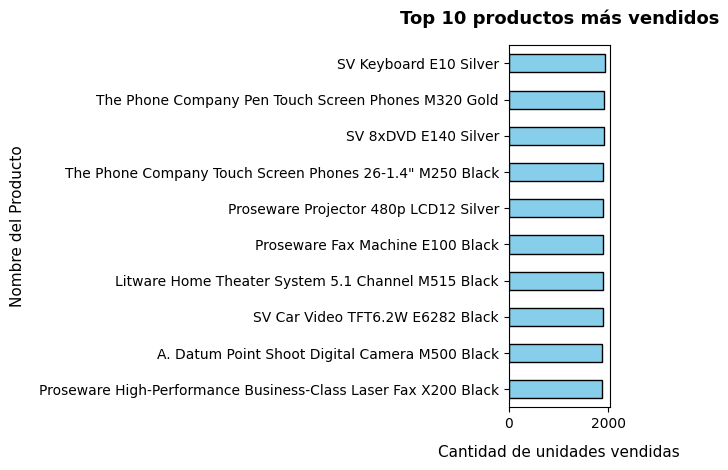

In [289]:
mapa_productos = dict(zip(tablas[2]['ProductKey'], tablas[2]['ProductName']))
top_nombres_productos = tablas[7]['ProductKey'].map(mapa_productos).value_counts().head(10)

top_nombres_productos.plot(kind='barh', color='skyblue', edgecolor='black') # Gráfico horizontal para leer nombres largos
plt.title("Top 10 productos más vendidos", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Cantidad de unidades vendidas", fontsize=11, labelpad=10)
plt.ylabel("Nombre del Producto", fontsize=11, labelpad=10)
plt.gca().invert_yaxis() # Pone el #1 arriba
plt.tight_layout()
plt.show()
#guardar("04_top10_productos")

*   **Gráfico que muestra la cantidad de unidades compradas según el precio unitario del producto**

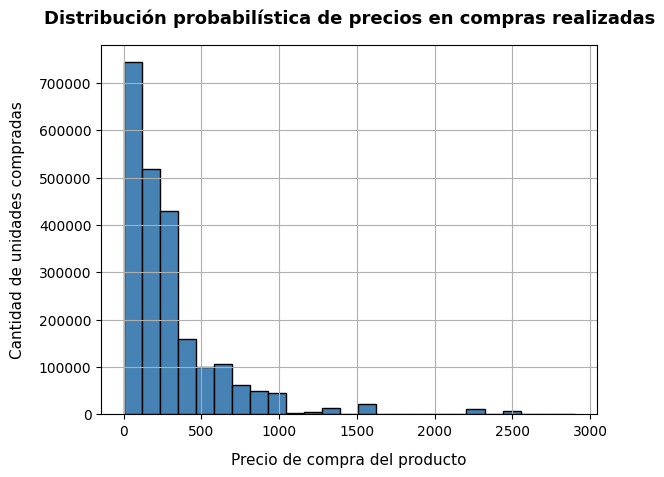

In [290]:
# Precio unitario del catálogo a cada transacción de ventas
mapa_precios = dict(zip(tablas[2]['ProductKey'], tablas[2]['UnitPrice']))
precios_compras = tablas[7]['ProductKey'].map(mapa_precios)

precios_compras.hist(bins=25, color='steelblue', edgecolor='black')
plt.title("Distribución probabilística de precios en compras realizadas", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Precio de compra del producto", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de unidades compradas", fontsize=11, labelpad=10)
plt.show()

*   **Gráfico que muestra la cantidad de compras según la promoción aplicada**

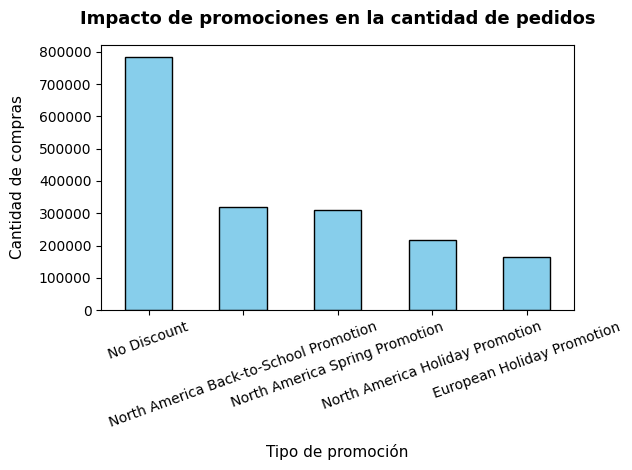

In [291]:
mapa_promo = dict(zip(tablas[5]['PromotionKey'], tablas[5]['PromotionName']))
ventas_promo = tablas[7]['PromotionKey'].map(mapa_promo).value_counts().head(5)

ventas_promo.plot(kind='bar', color='skyblue', edgecolor='black', rot=20)
plt.title("Impacto de promociones en la cantidad de pedidos", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Tipo de promoción", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de compras", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()
#guardar("06_impacto_promociones")

*   **Gráfico que muestra la cantidad de compras según el color del producto**

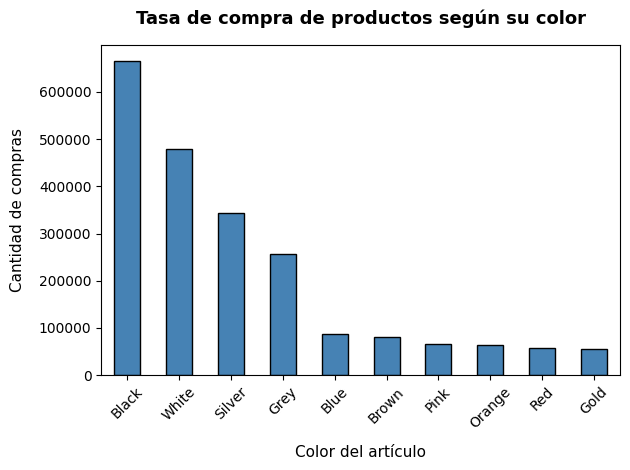

In [292]:
mapa_colores = dict(zip(tablas[2]['ProductKey'], tablas[2]['ColorName']))

ventas_colores = tablas[7]['ProductKey'].map(mapa_colores).value_counts().head(10)

ventas_colores.plot(kind='bar', color='steelblue', edgecolor='black', rot=45)
plt.title("Tasa de compra de productos según su color", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Color del artículo", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de compras", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()
#guardar("07_compras_por_color")

*   **Gráfico que muestra las 10 marcas con una variedad de productos en el inventario mayor**

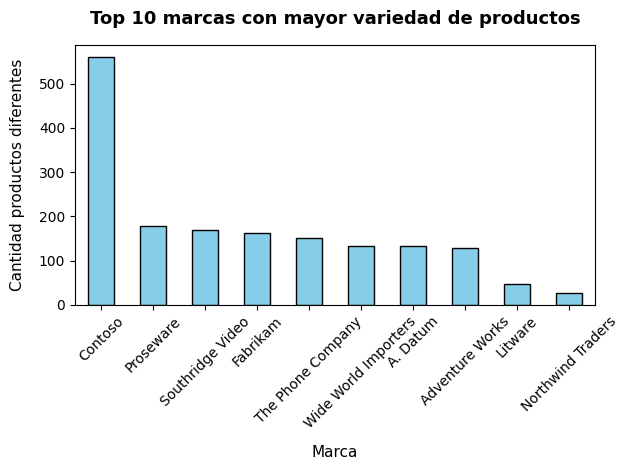

In [293]:
variedad_marcas = tablas[2]['BrandName'].value_counts().head(10)

variedad_marcas.plot(kind='bar', color='skyblue', edgecolor='black', rot=45)
plt.title("Top 10 marcas con mayor variedad de productos", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Marca", fontsize=11, labelpad=10)
plt.ylabel("Cantidad productos diferentes", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()
#guardar("08_variedad_marcas")

*   **Gráfico de caja que muestra la dispersión de los precios unitarios por categoría de producto**

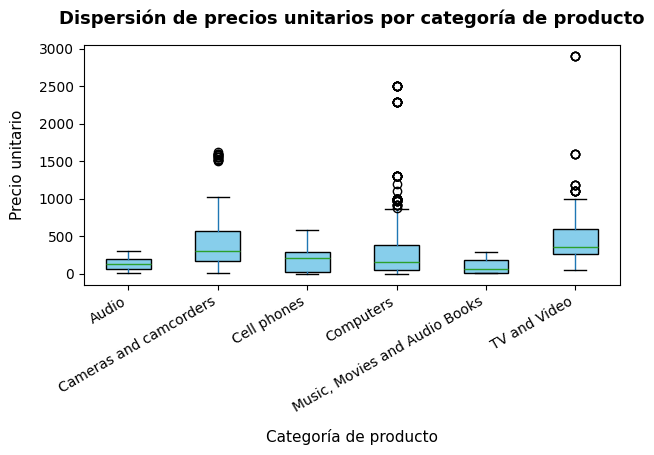

In [294]:
# Unimos subcategorías con categorías para tener el nombre completo
df_prod_cat = tablas[2].merge(tablas[4], on='ProductSubcategoryKey', how='left')
df_prod_cat = df_prod_cat.merge(tablas[3], on='ProductCategoryKey', how='left')

# Gráfico de cajas
df_prod_cat.boxplot(column='UnitPrice', by='ProductCategory', grid=False,
                     patch_artist=True, boxprops=dict(facecolor='skyblue', color='black'))

plt.title("Dispersión de precios unitarios por categoría de producto", fontsize=13, fontweight='bold', pad=15)
plt.suptitle("")
plt.xlabel("Categoría de producto", fontsize=11, labelpad=10)
plt.ylabel("Precio unitario", fontsize=11, labelpad=10)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
#guardar("09_boxplot_precio_categoria")

*   **Gráfico que muestra la cantidad de ventas que genera cada medio de distribución**

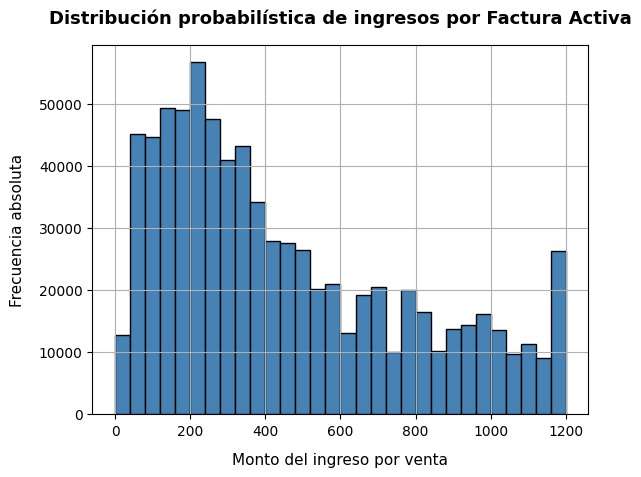

In [295]:
# Transacciones mayores a 0
ingresos_activos = tablas[7][tablas[7]['Ingresos'] > 0]['Ingresos']

ingresos_activos.hist(bins=30, color='steelblue', edgecolor='black', range=(0, 1200))
plt.title("Distribución probabilística de ingresos por Factura Activa", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Monto del ingreso por venta", fontsize=11, labelpad=10)
plt.ylabel("Frecuencia absoluta", fontsize=11, labelpad=10)
plt.show()
#guardar("10_distribucion_ingresos")

*   **Gráfico que muestra los países o regiones con mayor cantidad de compras**

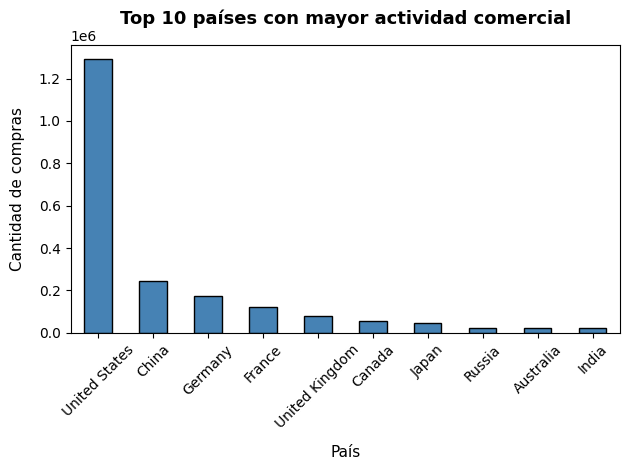

In [296]:
# Unimos tiendas con su geografía para obtener los nombres de las ubicaciones
df_tiendas_geo = tablas[6].merge(tablas[1], on='GeographyKey', how='left')
mapa_ciudades = dict(zip(df_tiendas_geo['StoreKey'], df_tiendas_geo['RegionCountryName']))

top_ciudades = tablas[7]['StoreKey'].map(mapa_ciudades).value_counts().head(10)

top_ciudades.plot(kind='bar', color='steelblue', edgecolor='black', rot=45)
plt.title("Top 10 países con mayor actividad comercial", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("País", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de compras", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()
#guardar("11_top10_paises")

*   **Gráfico que muestra los continentes en donde se registran la mayor cantidad de compras**

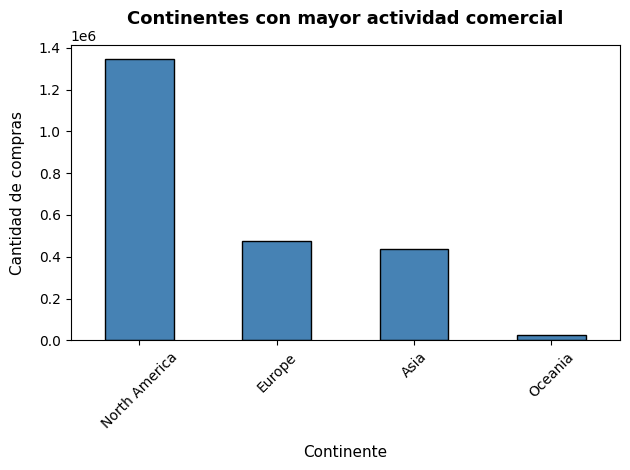

In [297]:
# Unimos tiendas con su geografía para obtener los nombres de las ubicaciones
df_tiendas_geo = tablas[6].merge(tablas[1], on='GeographyKey', how='left')
mapa_ciudades = dict(zip(df_tiendas_geo['StoreKey'], df_tiendas_geo['ContinentName']))

top_ciudades = tablas[7]['StoreKey'].map(mapa_ciudades).value_counts().head(10)

top_ciudades.plot(kind='bar', color='steelblue', edgecolor='black', rot=45)
plt.title("Continentes con mayor actividad comercial", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Continente", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de compras", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()
#guardar("12_continentes")

*   **Gráfico que muestra la relación entre la cantidad de compras y los meses en que se realizaron**

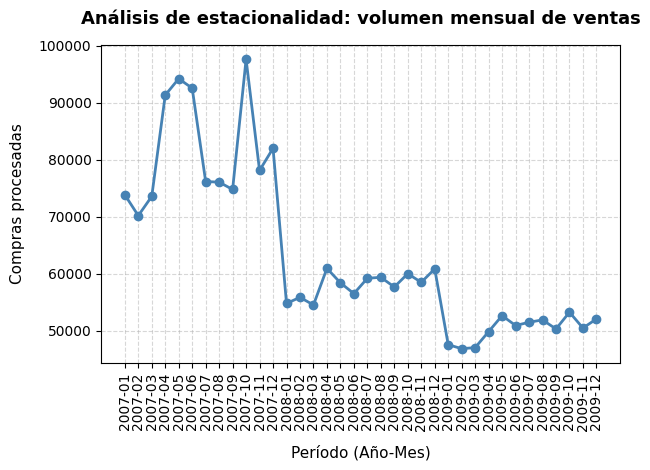

In [298]:
# Extraemos el mes de la transacción
ventas_mensuales = tablas[7]['DateKey'].dt.to_period('M').value_counts().sort_index()

plt.plot(ventas_mensuales.index.astype(str), ventas_mensuales.values, color='steelblue', marker='o', linewidth=2)
plt.title("Análisis de estacionalidad: volumen mensual de ventas", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Período (Año-Mes)", fontsize=11, labelpad=10, )
plt.ylabel("Compras procesadas", fontsize=11, labelpad=10)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
#guardar("13_estacionalidad_mensual")

*   **Gráfico que muestra la relación entre la cantidad de compras y los meses en que se realizaron**

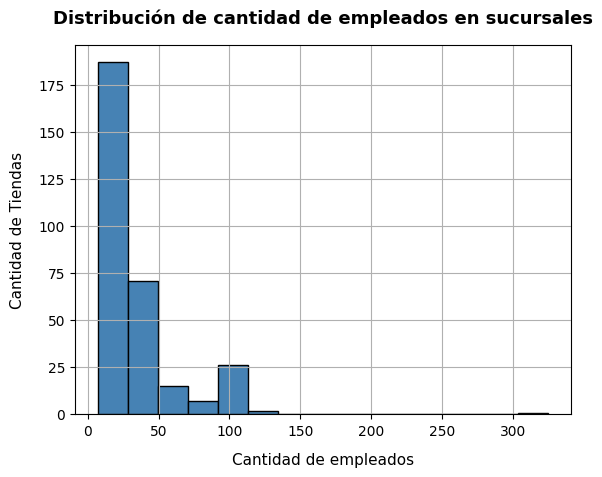

In [299]:
columna_tamaño = 'EmployeeCount' if 'EmployeeCount' in tablas[6].columns else tablas[6].select_dtypes(include=[np.number]).columns[1]

tablas[6][columna_tamaño].hist(bins=15, color='steelblue', edgecolor='black')
plt.title(f"Distribución de cantidad de empleados en sucursales", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Cantidad de empleados", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Tiendas", fontsize=11, labelpad=10)
plt.show()
#guardar("14_empleados_por_tienda")

In [300]:
df_ventas.to_csv('FactSales_Procesado.csv', index=False, sep=";")

In [301]:
#files.download('FactSales_Procesado.csv')